## Task 1: Exploratory Data Analysis (EDA):

**1.	Load the dataset and perform basic data exploration.**

**2.	Examine the distribution of features using histograms, box plots, or density plots.**

**3.	Investigate correlations between features to understand relationships within the data.**


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('dataset/wine.csv')

In [21]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [23]:
df['Type'].unique()

array([1, 2, 3], dtype=int64)

In [24]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [25]:
df.shape

(178, 14)

In [26]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [27]:
df["Type"].value_counts()

Type
2    71
1    59
3    48
Name: count, dtype: int64

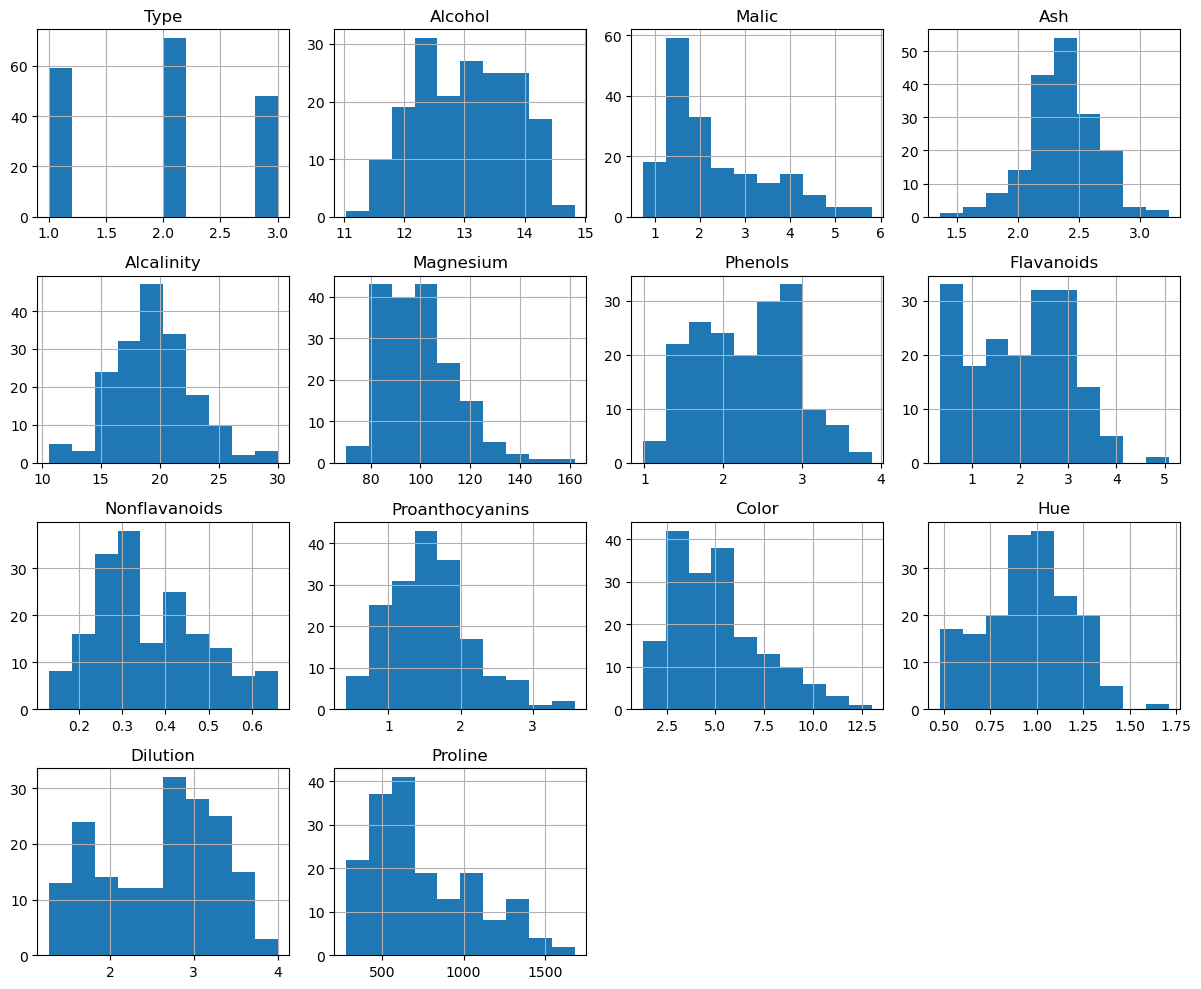

In [28]:
# Histogram 

df.hist(figsize=(12,10), bins=10)
plt.tight_layout()
plt.show()

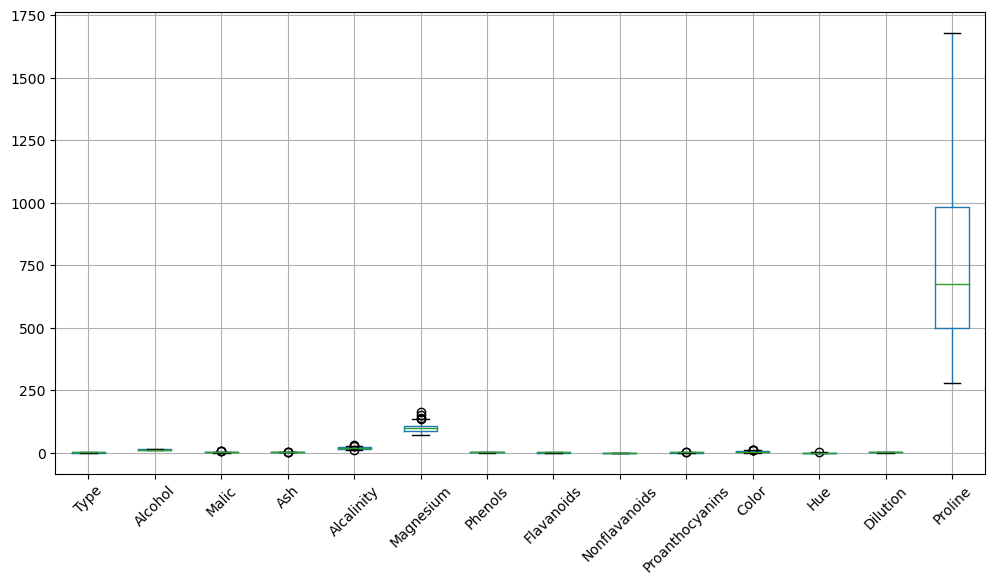

In [29]:
# Boxplot 

plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [30]:
# Outler Removal 
num_cols = df.drop('Type', axis=1).columns

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    
    UE = Q3 + 1.5*IQR
    LE = Q1 - 1.5*IQR
    
    df.loc[df[col] > UE, col] = UE
    df.loc[df[col] < LE, col] = LE

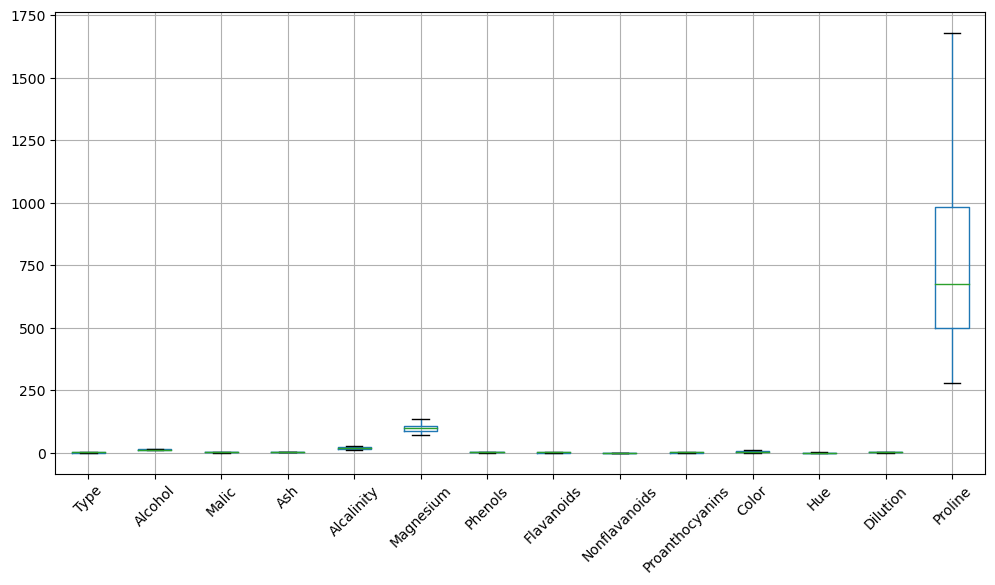

In [31]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

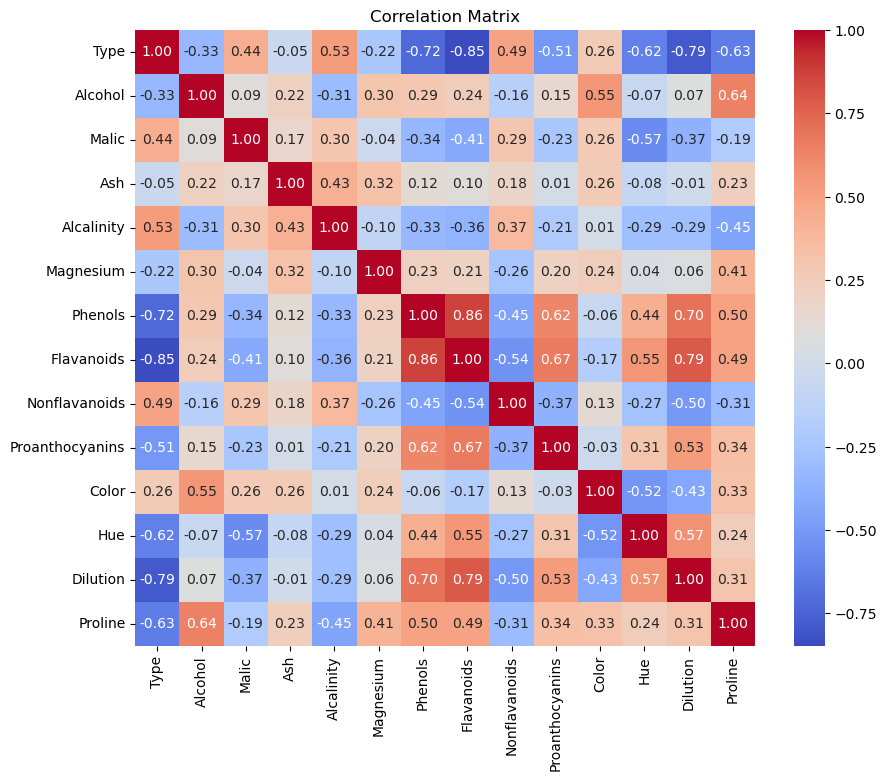

In [32]:
# Correlation Matrix

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

The Wine dataset consists of 178 observations with 13 numerical chemical attributes and a three-class target variable. No missing values were found in the dataset. Outlier detection was performed using the IQR method, and extreme values were capped to reduce the influence of anomalies while preserving dataset size.

The correlation analysis reveals strong relationships among several features. A very strong positive correlation exists between Phenols and Flavanoids (0.86), as well as between Flavanoids and Dilution (0.79). Additionally, Phenols and Dilution (0.70) show a high positive correlation. Strong negative correlations are observed between Type and Flavanoids (-0.85), Type and Dilution (-0.79), and Type and Phenols (-0.72), indicating these features significantly differentiate wine classes.

## Task 2: Dimensionality Reduction with PCA:

**1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.**

**2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.** 

**3.	Transform the original dataset into the principal components.**


In [33]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Type', axis=1)
y = df['Type']

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [34]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

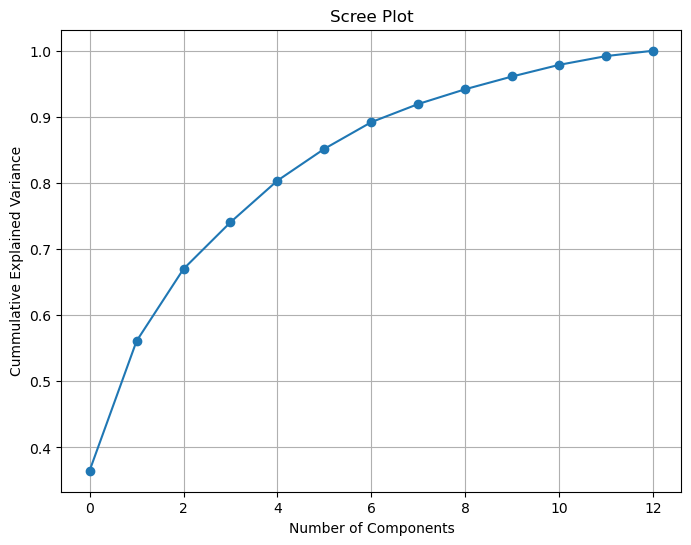

In [35]:
# Determine Optimal no. of components

plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cummulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [36]:
pca.explained_variance_ratio_

array([0.36475803, 0.19609775, 0.10911182, 0.07062378, 0.06296983,
       0.04815067, 0.04031504, 0.02744533, 0.02232516, 0.01931106,
       0.01755433, 0.01326634, 0.00807088])

In [37]:
np.cumsum(pca.explained_variance_ratio_)

array([0.36475803, 0.56085577, 0.66996759, 0.74059137, 0.8035612 ,
       0.85171187, 0.89202691, 0.91947224, 0.9417974 , 0.96110846,
       0.97866279, 0.99192912, 1.        ])

Since the first 8 principal components explain approximately 91.95% of the total variance, we reduce the dataset from 13 features to 8 components while preserving most of the information.

In [38]:
# Apply PCA with 8 Components

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

print('Original Shape: ', X_scaled.shape)
print('Shape after PCA: ', X_pca.shape)

Original Shape:  (178, 13)
Shape after PCA:  (178, 8)


Before applying PCA, all features were standardized using StandardScaler to ensure zero mean and unit variance, as PCA is sensitive to differences in feature scale. PCA was then implemented on the standardized dataset to transform the original correlated variables into a new set of orthogonal principal components.

The scree plot and cumulative explained variance were used to determine the optimal number of components. Based on the cumulative explained variance analysis, the first eight principal components account for approximately 91.95% of the total variance in the dataset. Therefore, the dimensionality of the dataset was reduced from 13 original features to 8 principal components. This reduction significantly decreases feature redundancy while retaining most of the meaningful information present in the data.

## Task 3: Clustering with Original Data:

**1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.**

**2.	Visualize the clustering results using appropriate plots.**

**3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.**


In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.predict(X_scaled)

df['Cluster'] = clusters

C:\Users\abhib\Desktop\ml_project\env\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\abhib\Desktop\ml_project\env\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


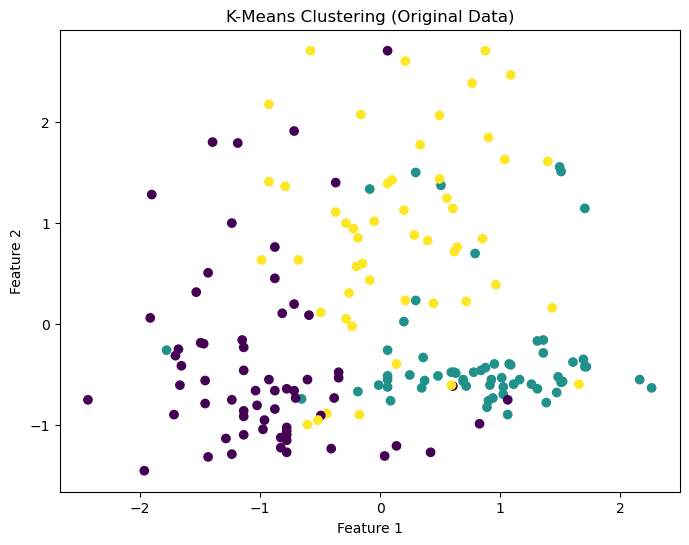

In [47]:
# Visualizing Clustering Results

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering (Original Data)')
plt.show()

In [50]:
# Evaluation

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, clusters)
print('Silhouette Score: ', np.round(sil_score,3))


Silhouette Score:  0.285


In [51]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_scaled, clusters)
print('Davies-Bouldin Index: ', np.round(db_score,3))

Davies-Bouldin Index:  1.382


K-Means clustering was applied to the standardized Wine dataset using three clusters, corresponding to the known wine types. Since clustering algorithms are distance-based, feature standardization was performed prior to model fitting. The clustering results were visualized.The clustering performance was evaluated using the Silhouette Score (0.285) and the Davies–Bouldin Index (1.382).

## Task 4: Clustering with PCA Data:

**1.	Apply the same clustering algorithm to the PCA-transformed dataset.**

**2.	Visualize the clustering results obtained from PCA-transformed data.**

**3.	Compare the clustering results from PCA-transformed data with those from the original dataset.**


In [55]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

df['Cluster_PCA'] = clusters_pca

C:\Users\abhib\Desktop\ml_project\env\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\abhib\Desktop\ml_project\env\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


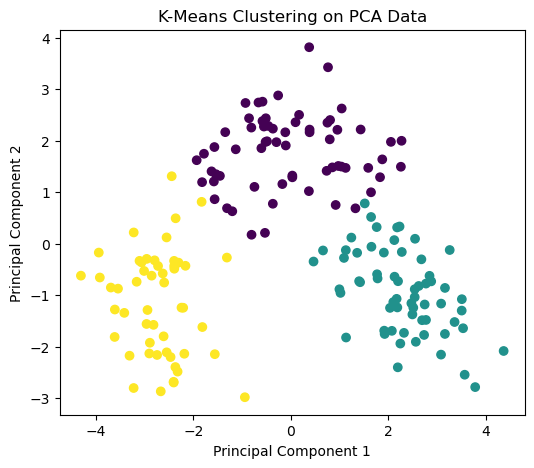

In [56]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on PCA Data")
plt.show()

In [57]:
sil_score_pca = silhouette_score(X_pca, clusters_pca)
db_score_pca = davies_bouldin_score(X_pca, clusters_pca)

print("Silhouette Score (PCA):", round(sil_score_pca,3))
print("Davies-Bouldin Index (PCA):", round(db_score_pca,3))

Silhouette Score (PCA): 0.315
Davies-Bouldin Index (PCA): 1.261


K-Means clustering was applied to the PCA-transformed dataset using eight principal components. The PCA-based clustering achieved a Silhouette Score of 0.315 and a Davies–Bouldin Index of 1.261, indicating improved cluster separation and compactness compared to clustering on the original dataset.

## Task 5: Comparison and Analysis:

**1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.**

**2.	Discuss any similarities or differences observed in the clustering results.**

**3.	Reflect on the impact of dimensionality reduction on clustering performance.**

**4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.**

The clustering results from the original dataset and the PCA-transformed dataset show noticeable differences in performance. When K-Means was applied to the original standardized dataset, the Silhouette Score was 0.285 and the Davies–Bouldin Index was 1.382, indicating moderate cluster separation. After applying PCA (retaining ~91.95% variance), clustering performance improved, with a Silhouette Score of 0.315 and a Davies–Bouldin Index of 1.261, suggesting better-defined and more compact clusters.

The primary similarity between both approaches is that K-Means was able to detect an underlying cluster structure in both cases. However, the PCA-transformed data produced slightly improved separation and reduced cluster overlap. This improvement occurs because PCA removes multicollinearity and redundant information by projecting data onto orthogonal components that capture maximum variance.

Dimensionality reduction positively impacted clustering performance by simplifying the feature space and enhancing cluster compactness. By focusing on the most informative components, PCA reduced noise and improved interpretability of cluster visualization.

However, there are trade-offs. While PCA improves computational efficiency and cluster quality, it reduces direct interpretability of original features, as principal components are linear combinations of variables. Clustering directly on the original dataset preserves feature interpretability but may suffer from redundancy and weaker separation due to correlated variables.


## Task 6: Conclusion and Insights

**1.	Summarize the key findings and insights from the assignment.**

The analysis demonstrated that the Wine dataset contains strong inter-feature correlations, indicating the presence of multicollinearity. Principal Component Analysis (PCA) successfully reduced the dimensionality from 13 features to 8 principal components while retaining approximately 91.95% of the total variance. This reduction minimized redundancy and preserved the most informative patterns in the data.

Clustering using K-Means on both the original and PCA-transformed datasets revealed that dimensionality reduction improved cluster quality. The PCA-based clustering achieved a higher Silhouette Score (0.315 vs 0.285) and a lower Davies–Bouldin Index (1.261 vs 1.382), indicating better cluster separation and compactness. This shows that PCA enhances clustering performance by reducing noise and correlated features.

**2.	Discuss the practical implications of using PCA and clustering in data analysis.**

From a practical perspective, PCA is highly useful when dealing with high-dimensional data containing correlated variables. It improves computational efficiency, reduces complexity, and enhances visualization. Clustering, on the other hand, is valuable for identifying hidden patterns and grouping similar observations in unlabeled data.


**3.	Provide recommendations for when to use each technique based on the analysis conducted**

Based on this analysis, PCA should be used when the dataset has many correlated features or when visualization and dimensionality reduction are required. Clustering can be applied directly when interpretability of original features is important, but combining PCA with clustering is recommended when improving cluster structure and efficiency is a priority.
